# US Health Insurance Dataset

https://www.youtube.com/watch?v=tEH5EuKPHa8

https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset/code

In [55]:
import pandas as pd

df = pd.read_csv('../../data/insurance.csv')
df[:5]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [56]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [57]:
df = df.rename(columns={"sex": "gender"})

In [58]:
df[:5]

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [59]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Interpretation of df.describe():

- Age and BMI have similar value ranges and averages
- Children column only ranges from 0 to 5
- Charges are from ~11k up to 63.7k

Since these values are so different this dataset will likely need to be scaled in some way.
Either by using Min-Max or Z-Standardization.

Region should be One-Hot encoded (binary), as the values are not scalable.

In [60]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [61]:
duplicate_rows_df = df[df.duplicated()]

print("number of duplicate rows: ", duplicate_rows_df.shape)
print("number of total rows: ", df.shape)

number of duplicate rows:  (1, 7)
number of total rows:  (1338, 7)


In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.shape

(1337, 7)

### Visualization

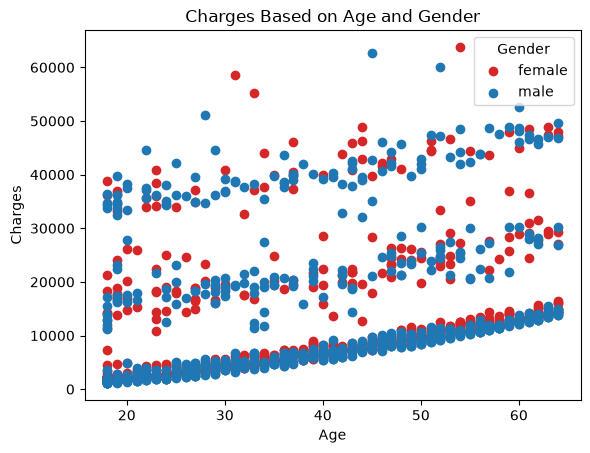

In [64]:
from matplotlib import pyplot as plt

# Define colors for each gender
gender_colors = {'male': 'tab:blue', 'female': 'tab:red'}

# Iterate through the DataFrame and plot points with corresponding colors
for gender, group in df.groupby('gender'):
    plt.scatter(group['age'], group['charges'], label=gender, color=gender_colors[gender])

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Charges Based on Age and Gender')

# Add a legend to distinguish genders
plt.legend(title='Gender')

# Show the plot
plt.show()

# The plost shows there isn't much correlation between insurance cost and gender

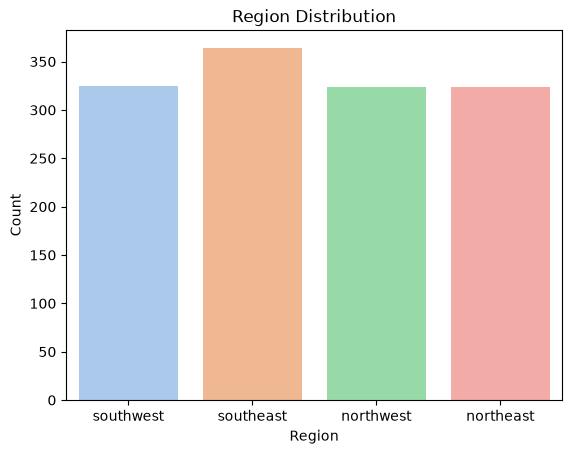

In [65]:
import seaborn as sns

# plotting the distibution of the 'region' feature
sns.countplot(x='region', data=df, palette='pastel', hue='region')
plt.title('Region Distribution')
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

# From the figure above, data seems to equally spacially / geologically distributed.
# An explanation for why southeast might have a slightly higher value is because of Florida's population density affecting the rest.

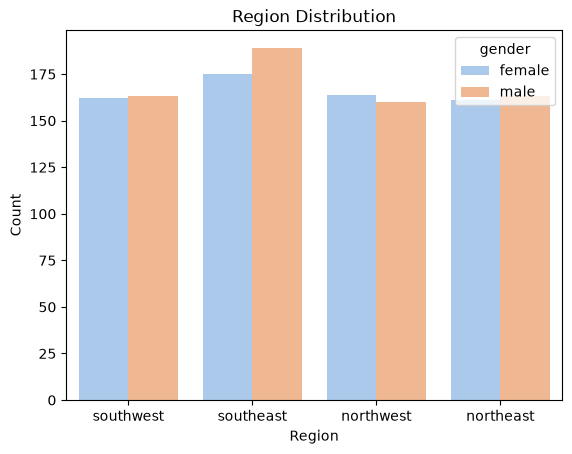

In [66]:
# plotting the distibution of the 'region' feature
sns.countplot(x='region', data=df, palette='pastel', hue='gender')
plt.title('Region Distribution')
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

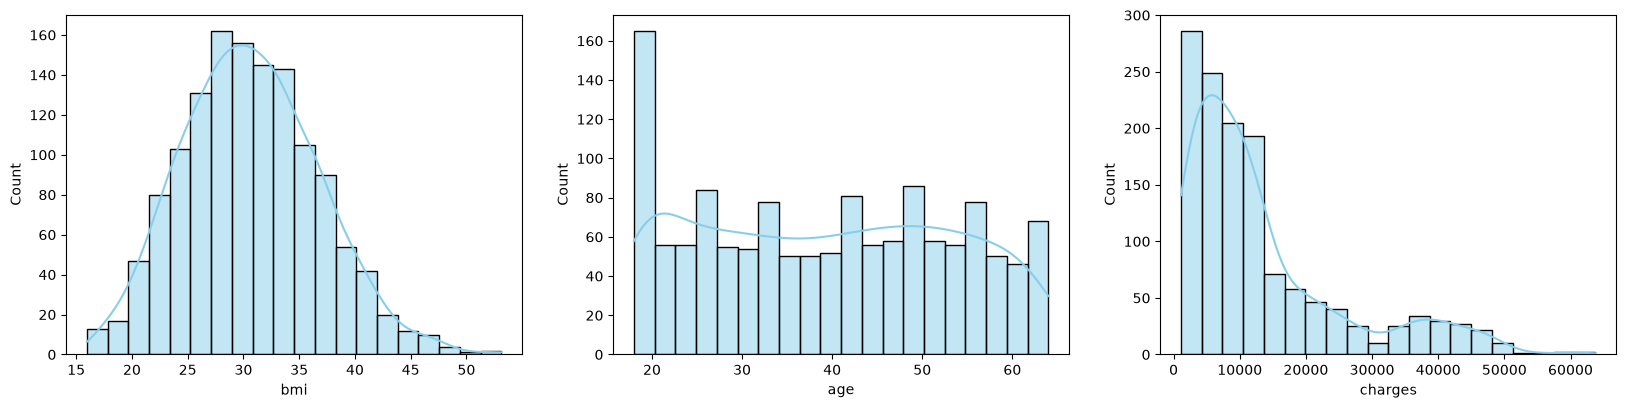

In [67]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 1)
sns.histplot(df['bmi'], kde=True, color='skyblue', bins=20)
plt.xlabel('bmi')

plt.subplot(3, 3, 2)
sns.histplot(df['age'], kde=True, color='skyblue', bins=20)
plt.xlabel('age')

plt.subplot(3, 3, 3)
sns.histplot(df['charges'], kde=True, color='skyblue', bins=20)
plt.xlabel('charges')

plt.show()

# From the plots above:
# BMI frequency - values are normally distributed
# Age frequency - most data points are from people in their 20s with peaks at every ~5 year interval (1 col. ~ 2.5 years)
# Charges - most values are around 10k and below

### Preprocessing

In [70]:
pd.get_dummies(df.region, dtype=int)
df = df.join(pd.get_dummies(df.region, dtype=int)).drop('region', axis=1)
df[:5]

,age,gender,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [71]:
# encode categorical features with more than two categories
# multiclass_features = ['region']
# df = pd.get_dummies(df, columns = multiclass_features, drop_first = True, dtype = int)


In [72]:
from sklearn.preprocessing import LabelEncoder

# initialize encoder
le = LabelEncoder()

# encode binary categorical features
binary_features = ['gender', 'smoker']
for feature in binary_features:
    df[feature] = le.fit_transform(df[feature])

# df['gender'] = df['gender'].apply(lambda x: 1 if x == 'male' else 0)
# df['smoker'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)


df.head()

,age,gender,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'charges'}>],
       [<Axes: title={'center': 'northeast'}>,
        <Axes: title={'center': 'northwest'}>,
        <Axes: title={'center': 'southeast'}>],
       [<Axes: title={'center': 'southwest'}>, <Axes: >, <Axes: >]],
      dtype=object)

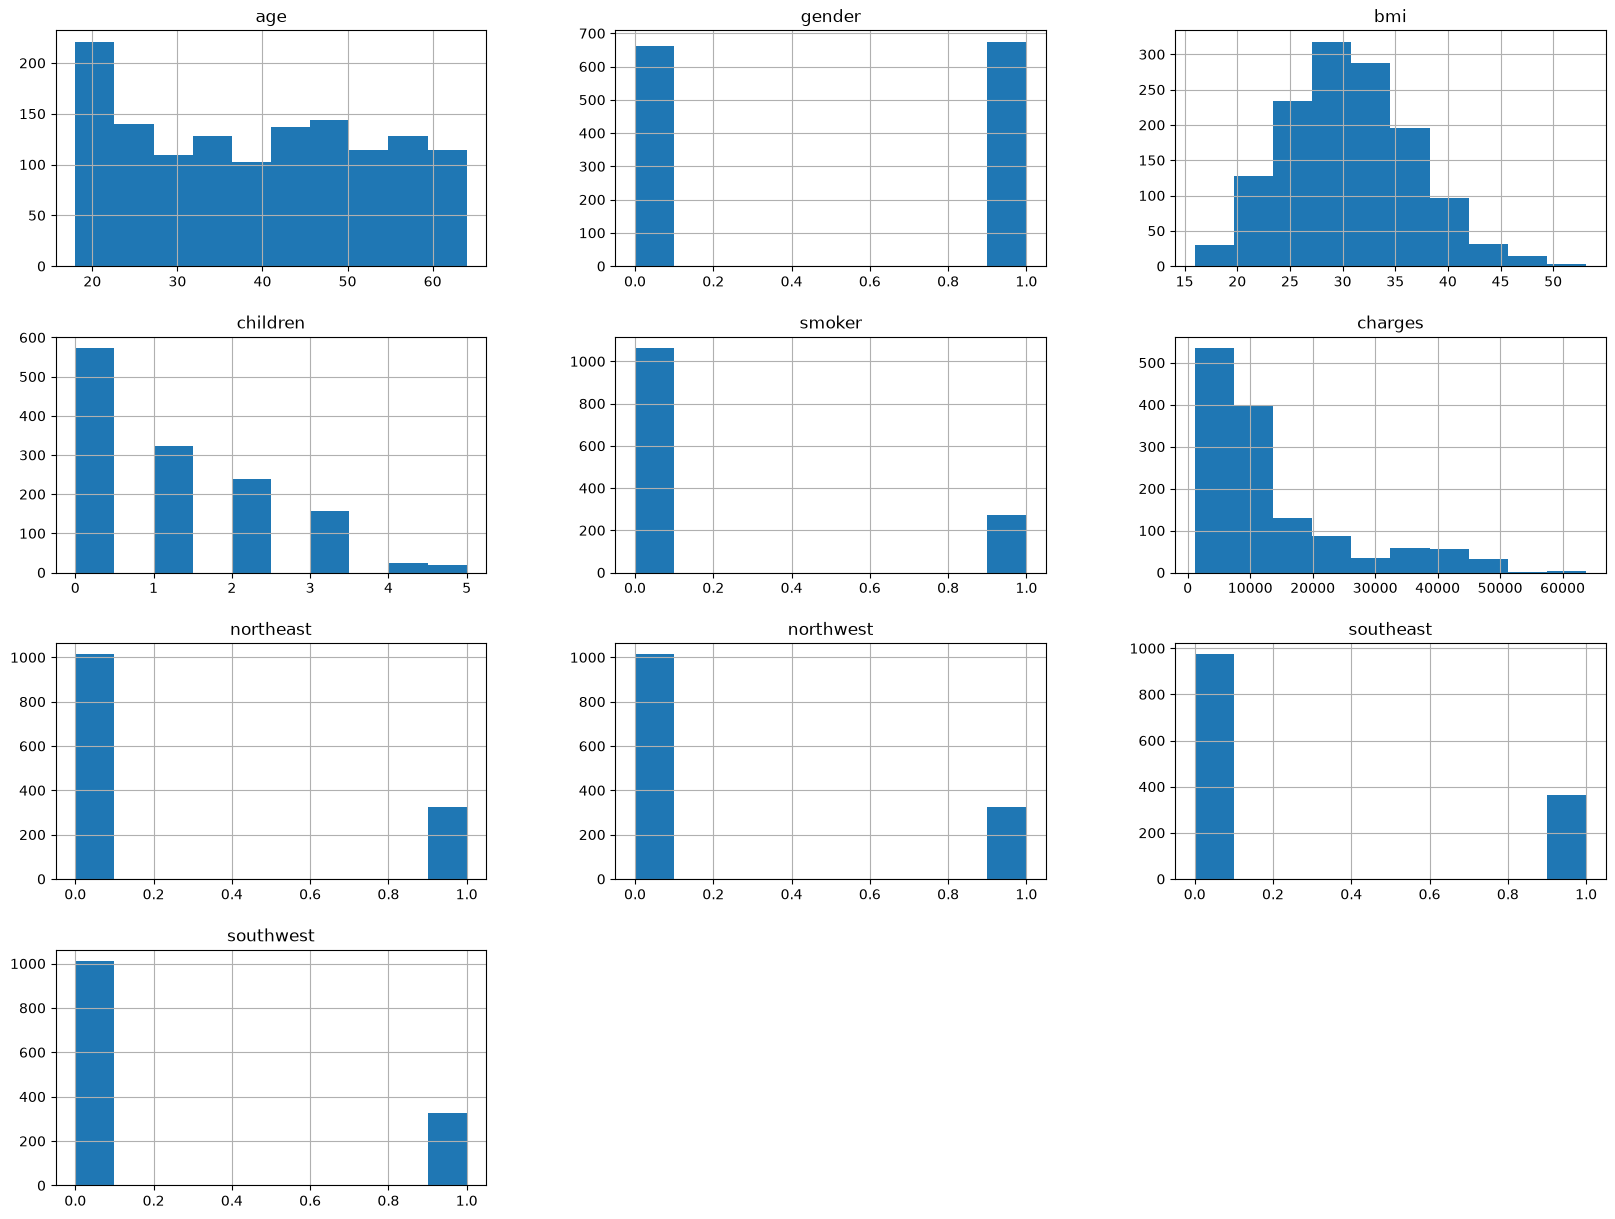

In [74]:
df.hist(figsize=(20, 15))

In [75]:
df.corr()

,age,gender,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308,0.001868,0.001495,-0.012311,0.009415
gender,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044,-0.002008,-0.012482,0.017578,-0.003767
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401,-0.138178,-0.136138,0.270057,-0.006211
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389,-0.023202,0.026044,-0.023492,0.021538
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234,0.002597,-0.036321,0.068282,-0.037168
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000,0.005945,-0.038695,0.073578,-0.043637
northeast,0.001868,-0.002008,-0.138178,-0.023202,0.002597,0.005945,1.000000,-0.319842,-0.345909,-0.320493
northwest,0.001495,-0.012482,-0.136138,0.026044,-0.036321,-0.038695,-0.319842,1.000000,-0.345909,-0.320493
southeast,-0.012311,0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,-0.345909,1.000000,-0.346614
southwest,0.009415,-0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.320493,-0.346614,1.000000


<Axes: >

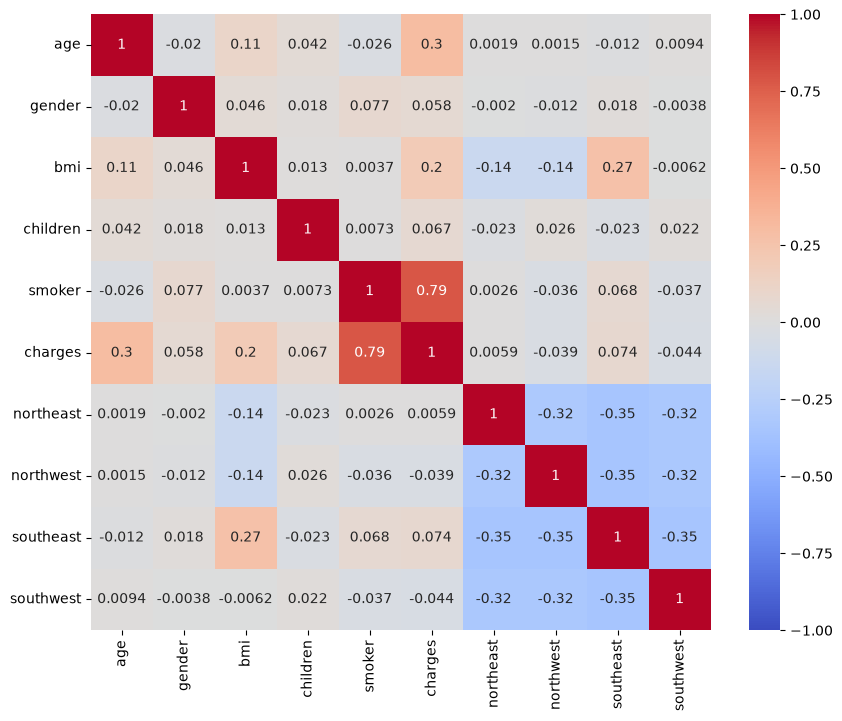

In [77]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# Correlation plot Interpretation:
# By checking either the charges column or row cell by cell, it can be seen that smoking, age, and bmi all lead to and an increase in insurance charge.
# With smoking being the most significant at 0.79.

In [78]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# TODO scaling (we skip this now)
numerical_features = ['age', 'bmi', 'children', 'charges']

# Feature Scaling with StandardScaler
df_standard_scaled = df.copy()
df_standard_scaled[numerical_features] = StandardScaler().fit_transform(df[numerical_features])

# Feature Scaling with MinMaxScaler
df_minmax_scaled = df.copy()
df_minmax_scaled[numerical_features] = MinMaxScaler().fit_transform(df[numerical_features])

In [79]:
df_standard_scaled.head()

,age,gender,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,-1.440418,0,-0.453160,-0.909234,1,0.297857,0,0,0,1
1,-1.511647,1,0.509422,-0.079442,0,-0.954381,0,0,1,0
2,-0.799350,1,0.383155,1.580143,0,-0.729373,0,0,1,0
3,-0.443201,1,-1.305052,-0.909234,0,0.719104,0,1,0,0
4,-0.514431,1,-0.292456,-0.909234,0,-0.777499,0,1,0,0


In [80]:
df_minmax_scaled.head()

# The difference between the two methods above is that Min-Max only has positive values from (0 to 1).
# While Standard Scaler translates the values of each feature into Z scores with Std. dev = 1, and mean = 0

,age,gender,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,0.021739,0,0.321227,0.0,1,0.251611,0,0,0,1
1,0.000000,1,0.479150,0.2,0,0.009636,0,0,1,0
2,0.217391,1,0.458434,0.6,0,0.053115,0,0,1,0
3,0.326087,1,0.181464,0.0,0,0.333010,0,1,0,0
4,0.304348,1,0.347592,0.0,0,0.043816,0,1,0,0


### Prediction

**Which Algorithms to use**

To help in choosing what Machine learning algorithms will get the best results, it's important to define what type of problem it is.

Since all the data is labeled; it's a supervised learning problem, with the objective being predicting a numerical value (insurance rate / charge $) based on the input variables, meaning that it's a regression problem.

- Linear Regression - LinearRegression
- Decision Trees - DecisionTreeRegressor
- Random Forest - RandomForestRegressor
- Gradient Boosting - such as GradientBoostingRegressor, XGBoost or LGBMRegressor

In [81]:
# TODO use df_minmax_scaled (not df)

X = df.drop('charges', axis=1)
y = df['charges']

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

print("The shape of each data segment:")
print(" X_train :", X_train.shape)
print(" y_train :", y_train.shape, "\n")
print(" X_test  :", X_test.shape)
print(" y_test :", y_test.shape)

The shape of each data segment:
 X_train : (1069, 9)
 y_train : (1069,) 

 X_test  : (268, 9)
 y_test : (268,)


In [84]:
from sklearn.ensemble import RandomForestRegressor

# n_jobs=-1 -- use all cpu
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equ

In [85]:
model.score(X_test, y_test)

0.8301839187703758

In [86]:
y_pred = model.predict(X_test)

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, \
    root_mean_squared_error

# Set up the metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Print calculations
print(f'Test set errors:')
print(f'MAE: {mae:,.3f}')
print(f'RMSE : {rmse:,.3f}')
print(f'MSE : {mse:,.3f}')
print(f'MAPE: {mape:,.3f}')

Test set errors:
MAE: 2,587.157
RMSE : 4,686.937
MSE : 21,967,378.245
MAPE: 0.356


In [88]:
df.charges.std()

np.float64(12110.359656344175)

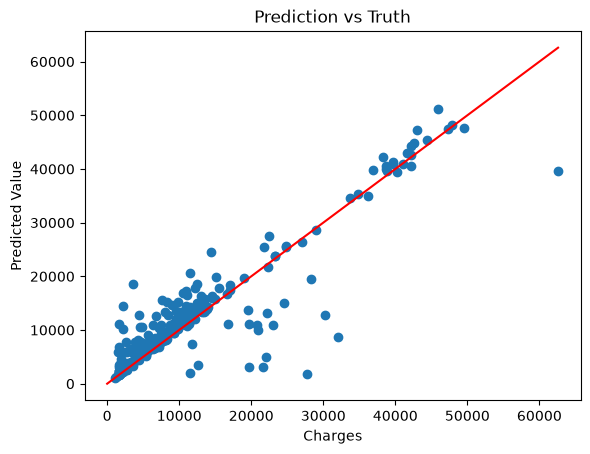

In [92]:
import numpy as np

plt.scatter(y_test, y_pred)
plt.plot(np.linspace(0, max(y_test)), np.linspace(0, max(y_test)), color='red')
plt.xlabel('Charges')
plt.ylabel('Predicted Value')
plt.title('Prediction vs Truth')
plt.show()

In [93]:
# TODO scaled df, different models...

In [98]:
feature_importances = sorted(zip(model.feature_names_in_, model.feature_importances_), key=lambda x: x[1], reverse=True)

Text(0.5, 1.0, 'Feature Importances')

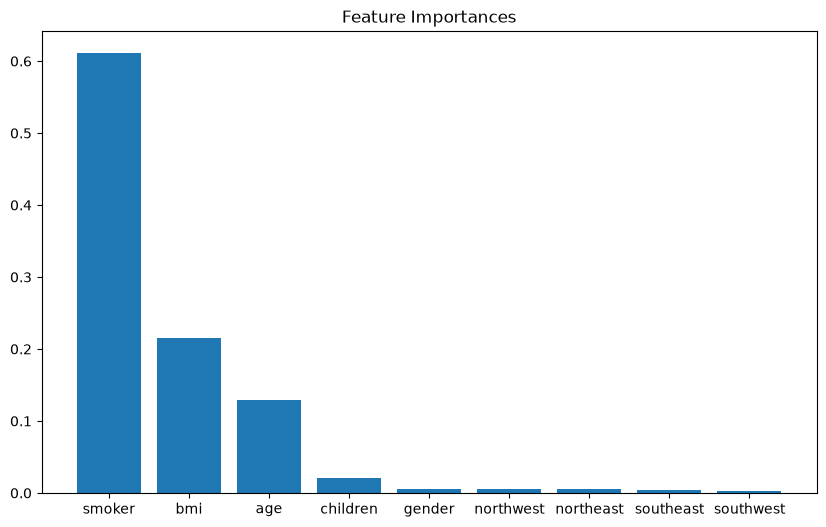

In [99]:
plt.figure(figsize=(10, 6))
plt.bar([x[0] for x in feature_importances], [x[1] for x in feature_importances])
plt.title('Feature Importances')

### hyper parameter tuning

In [101]:
from sklearn.model_selection import GridSearchCV

# trying all the configurations
param_grid = {
    'max_depth': [None, 2, 5],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
}

model = RandomForestRegressor(n_jobs=-1)

# cv = folding
grid_search = GridSearchCV(model, param_grid, cv=5)

In [102]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...sor(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [103]:
grid_search.best_params_

{'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 8}

In [104]:
grid_search.best_score_

np.float64(0.857048216647522)

In [107]:
# if i have params at the edge, try to add more, like max_depth = 6 ?

best_model = grid_search.best_estimator_
best_model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal 

In [108]:
best_model.score(X_test, y_test)

0.866936044164044